# Install Required Libraries
Install necessary libraries such as PyTorch, segmentation_models_pytorch, and other dependencies using pip.

## Connect to GPU
Connect the T4 machine on top right

In [ ]:
 # Install Required Libraries
!pip install torch torchvision segmentation-models-pytorch matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 18.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [ ]:
# Import Necessary Modules
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_tensor, resize
import segmentation_models_pytorch as smp

# Load the Pretrained Model
Load the saved model weights using `torch.load` and initialize the model architecture.

The model can be downloaded at https://drive.google.com/file/d/1Wx3Pcp2NeSIPB-78nWKpwJ-brCxEJWlz/view?usp=sharing

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=5  # Number of classes in the segmentation task
).to(device)

# Load the saved model weights
model_path = "best_model.pth"
model.load_state_dict(torch.load(model_path, map_location=device))

<All keys matched successfully>

# Input TIF file with just phalloidin channel

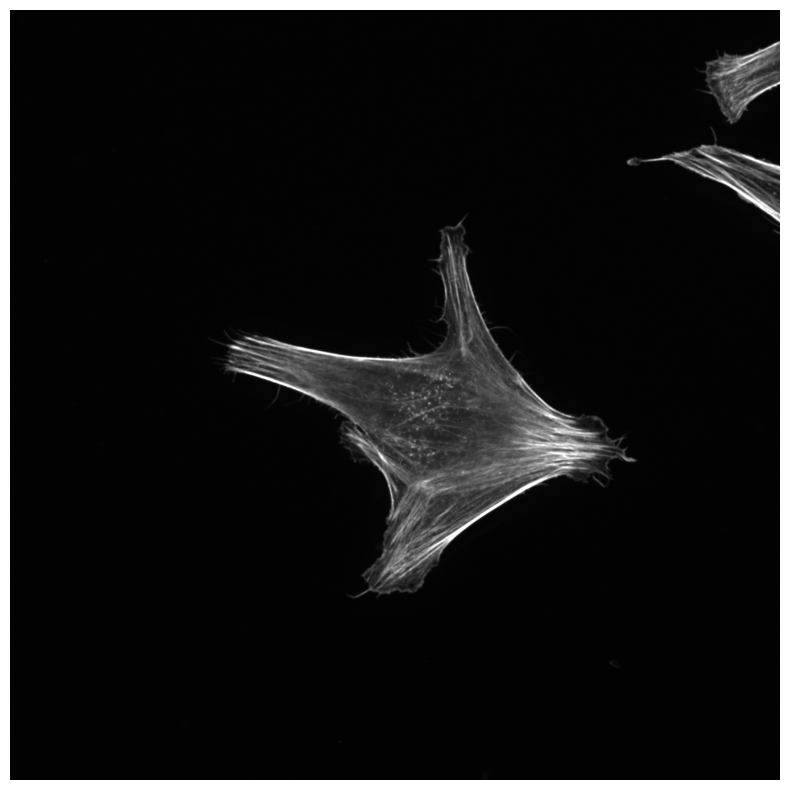

In [ ]:
import cv2
from matplotlib import pyplot as plt
from skimage.restoration import rolling_ball

image_path = "test.tif"
image = tiff.imread(image_path)

plt.figure(figsize=(10, 10))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

## Background subtraction

In [ ]:
from skimage import io
from skimage.restoration import rolling_ball
import matplotlib.pyplot as plt
from torchvision import transforms
transform = transforms.Compose([
    transforms.ToTensor(),
])

import cv2
import tifffile as tiff
from matplotlib import pyplot as plt
from skimage.restoration import rolling_ball

image_name = os.path.basename(image_path)
image = cv2.imread(image_name)

# Subtract background using rolling ball
background = rolling_ball(image, radius=50)
corrected = image - background

plt.imshow(corrected, cmap='gray')
plt.axis('off')
plt.show()

img_np = Image.fromarray(corrected).convert("L")
img = transform(img_np).unsqueeze(0).to(device)

# Run Inference on Test Images
Use the model to predict segmentation masks for the test images and decode the predictions into RGB masks.

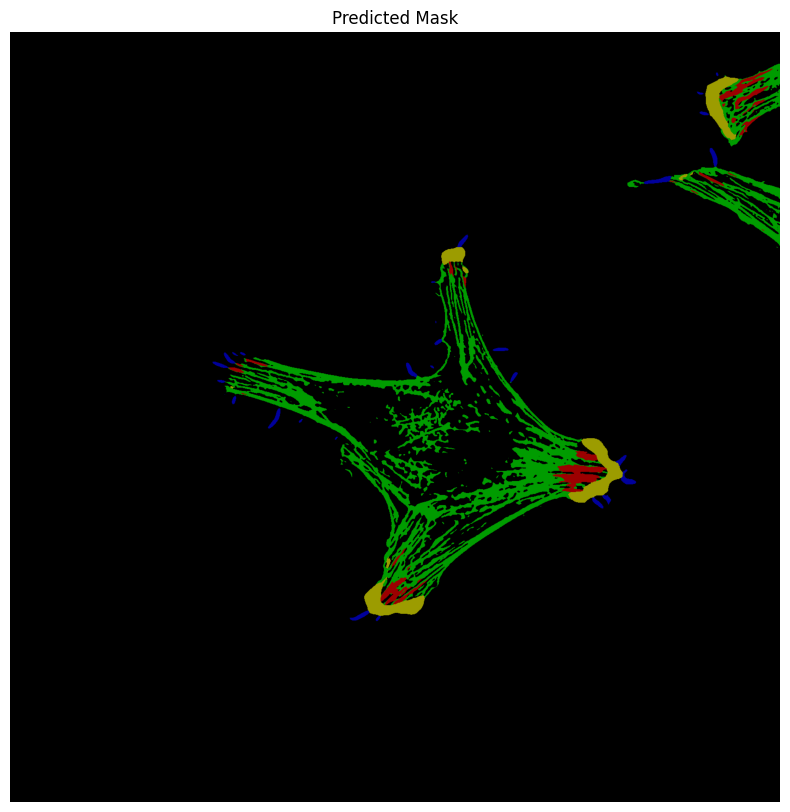

In [ ]:
# Run Inference on Test Images
def decode_segmentation_masks(mask, colormap, n_classes):
    r = np.zeros_like(mask).astype(np.uint8)
    g = np.zeros_like(mask).astype(np.uint8)
    b = np.zeros_like(mask).astype(np.uint8)
    for l in range(0, n_classes):
        idx = mask == l
        r[idx] = colormap[l, 0]
        g[idx] = colormap[l, 1]
        b[idx] = colormap[l, 2]
    rgb = np.stack([r, g, b], axis=2)
    return rgb

colormap = np.array([
    [0, 0, 0],       # Background - Black
    [0, 255, 0],     # Actin - Green
    [255, 0, 0],     # Focal Adhesions - Red
    [255, 255, 0],   # Lamellipodia - Yellow
    [0, 0, 255]      # Filopodia - Blue
], dtype=np.uint8)
colormap = colormap * 100
colormap = colormap.astype(np.uint8)



with torch.no_grad():
    output = model(img)
    _, pred = torch.max(output, 1)
    pred = pred.squeeze(0).cpu().numpy()
    decoded_pred = decode_segmentation_masks(pred, colormap, n_classes=5)

    plt.figure(figsize=(10, 10))
    plt.imshow(decoded_pred)
    plt.axis("off")
    plt.title(f"Predicted Mask")
    # plt.savefig(os.path.join(output_dir, f"predicted_{img_name}.png"))
    plt.show()